<a href="https://colab.research.google.com/github/gspark0714-cell/python_basic/blob/main/day4_%EC%97%B0%EA%B4%80%EB%B6%84%EC%84%9D_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import warnings
import logging
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

In [4]:
!pip install mlxtend -q
!apt-get install -y fonts-nanum -q
import matplotlib
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 7 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,334 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [5]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('군부대_탈영예측_연관분석.csv', encoding='utf-8-sig')
df = df.drop(columns=['병사ID'])

print("=== 데이터 크기 ===")
print(f"병사 수: {df.shape[0]}명, 변수 수: {df.shape[1]}개")
print(f"\n=== 탈영 발생률 ===")
print(f"탈영 발생: {df['탈영발생'].sum()}명 ({df['탈영발생'].mean()*100:.1f}%)")
print(f"탈영 미발생: {(df['탈영발생']==0).sum()}명 ({(1-df['탈영발생'].mean())*100:.1f}%)")

=== 데이터 크기 ===
병사 수: 500명, 변수 수: 9개

=== 탈영 발생률 ===
탈영 발생: 185명 (37.0%)
탈영 미발생: 315명 (63.0%)


In [6]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 값이 1인 항목만 트랜잭션에 포함
transactions = []
for _, row in df.iterrows():
    items = [col for col in df.columns if row[col] == 1]
    transactions.append(items)

# 원-핫 인코딩
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# 빈발 아이템셋 추출
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# 연관규칙 생성
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

print(f"전체 연관규칙 수: {len(rules)}")

전체 연관규칙 수: 3179


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
rules_target = rules[rules['consequents'].apply(lambda x: '탈영발생' in x)].copy()
rules_target['원인조합'] = rules_target['antecedents'].apply(lambda x: ' + '.join(list(x)))
rules_target = rules_target.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"탈영 촉진 조합 수: {len(rules_target)}개")
rules_target[['원인조합', 'support', 'confidence', 'lift']].head(20)

탈영 촉진 조합 수: 1100개


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,원인조합,support,confidence,lift
0,상담거부 + 외출제한 + 가족연락두절,0.068,0.507463,3.475772
1,상담거부 + 무단이탈경고 + 가족연락두절,0.068,0.548387,3.470804
2,훈련성적저하 + 무단이탈경고,0.068,0.459459,3.428802
3,상담거부 + 가족연락두절,0.068,0.400000,3.333333
4,외출제한 + 훈련성적저하 + 무단이탈경고,0.068,0.566667,3.333333
5,외출제한 + 훈련성적저하,0.068,0.409639,3.303537
6,상담거부 + 외출제한 + 무단이탈경고 + 가족연락두절,0.068,0.666667,3.300330
7,상담거부 + 외출제한 + 가족연락두절,0.068,0.507463,3.252966
8,동료갈등 + 훈련성적저하 + 가족연락두절,0.060,0.697674,3.229974
9,상담거부 + 훈련성적저하 + 무단이탈경고,0.068,0.755556,3.228870


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
rules_low = rules_target.sort_values('lift', ascending=True).copy()

# 원인조합 기준으로 중복 제거 (lift 가장 낮은 것만 유지)
rules_low = rules_low.drop_duplicates(subset=['원인조합']).reset_index(drop=True)

# lift < 1.0 이 없으면 하위 10개 출력
if len(rules_low[rules_low['lift'] < 1.0]) == 0:
    print("※ lift < 1.0 조합 없음 → 상대적으로 탈영 영향이 적은 조합 Top 10")
    rules_low = rules_low.head(10)

rules_low[['원인조합', 'support', 'confidence', 'lift']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

※ lift < 1.0 조합 없음 → 상대적으로 탈영 영향이 적은 조합 Top 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,원인조합,support,confidence,lift
0,수면장애,0.102,0.318750,1.410398
1,동료갈등,0.108,0.329268,1.630041
2,훈련성적저하,0.108,0.362416,1.647346
3,상담거부,0.102,0.356643,1.938279
4,동료갈등 + 수면장애,0.052,0.406250,2.011139
5,훈련성적저하 + 식사거부,0.056,0.451613,2.052786
6,훈련성적저하 + 수면장애,0.052,0.456140,2.073365
7,식사거부,0.084,0.336000,2.100000
8,외출제한,0.160,0.441989,2.104709
9,상담거부 + 훈련성적저하,0.066,0.471429,2.142857


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
#군부대 탈영예측 연관분석 V2

In [1]:
!pip install mlxtend -q
!apt-get install -y fonts-nanum -q

import warnings, logging
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import matplotlib
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [2]:
import pandas as pd

df = pd.read_csv('군부대_탈영예측_연관분석_v2.csv', encoding='utf-8-sig')
df = df.drop(columns=['병사ID'])

print(f"병사 수: {df.shape[0]}명 / 변수 수: {df.shape[1]}개")
print(f"탈영 발생: {df['탈영발생'].sum()}명 ({df['탈영발생'].mean()*100:.1f}%)")
print(f"탈영 미발생: {(df['탈영발생']==0).sum()}명 ({(1-df['탈영발생'].mean())*100:.1f}%)")

병사 수: 500명 / 변수 수: 21개
탈영 발생: 234명 (46.8%)
탈영 미발생: 266명 (53.2%)


In [3]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 값이 1인 항목만 트랜잭션에 포함
transactions = []
for _, row in df.iterrows():
    items = [col for col in df.columns if row[col] == 1]
    transactions.append(items)

# 원-핫 인코딩
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# 빈발 아이템셋 추출
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# 연관규칙 생성
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

print(f"전체 연관규칙 수: {len(rules)}")

전체 연관규칙 수: 414242


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# 탈영발생이 결과인 규칙 필터링
rules_high = rules[rules['consequents'].apply(lambda x: '탈영발생' in x)].copy()
rules_high['원인조합'] = rules_high['antecedents'].apply(lambda x: ' + '.join(sorted(list(x))))
rules_high = rules_high.sort_values('lift', ascending=False)
rules_high = rules_high.drop_duplicates(subset=['원인조합']).reset_index(drop=True)

print(f"탈영 촉진 조합 수: {len(rules_high)}개")
rules_high[['원인조합', 'support', 'confidence', 'lift']].head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

탈영 촉진 조합 수: 3685개


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,원인조합,support,confidence,lift
0,동료갈등 + 수면장애 + 식사거부 + 폭언폭행경험 + 훈련성적저하,0.050,0.396825,4.614249
1,동료갈등 + 수면장애 + 식사거부 + 음주문제 + 폭언폭행경험,0.050,0.390625,4.542151
2,동료갈등 + 수면장애 + 식사거부 + 폭언폭행경험,0.050,0.304878,4.483501
3,수면장애 + 식사거부 + 음주문제 + 폭언폭행경험,0.060,0.379747,4.415661
4,상담거부 + 수면장애 + 식사거부 + 음주문제,0.050,0.333333,4.385965
5,상담거부 + 수면장애 + 식사거부 + 음주문제 + 훈련성적저하,0.050,0.446429,4.376751
6,동료갈등 + 무단이탈경고 + 수면장애 + 스마트폰과의존 + 폭언폭행경험,0.050,0.462963,4.367575
7,수면장애 + 식사거부 + 폭언폭행경험 + 훈련성적저하,0.060,0.375000,4.360465
8,무단이탈경고 + 상담거부 + 스마트폰과의존 + 음주문제 + 훈련성적저하,0.050,0.555556,4.340278
9,무단이탈경고 + 스마트폰과의존 + 식사거부 + 음주문제 + 훈련성적저하,0.050,0.510204,4.323763


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# 탈영발생=0 이 결과인 규칙 → 탈영 억제 조합
# 탈영발생 열을 반전시켜 '안전'을 1로 만든 새 컬럼 활용
df2 = df.copy()
df2['병영생활안정'] = (df2['탈영발생'] == 0).astype(int)
df2 = df2.drop(columns=['탈영발생'])

transactions2 = []
for _, row in df2.iterrows():
    items = [col for col in df2.columns if row[col] == 1]
    transactions2.append(items)

te2 = TransactionEncoder()
te_array2 = te2.fit_transform(transactions2)
df_encoded2 = pd.DataFrame(te_array2, columns=te2.columns_)

frequent_itemsets2 = apriori(df_encoded2, min_support=0.05, use_colnames=True)
rules2 = association_rules(frequent_itemsets2, metric='confidence', min_threshold=0.3)

rules_low = rules2[rules2['consequents'].apply(lambda x: '병영생활안정' in x)].copy()
rules_low['원인조합'] = rules_low['antecedents'].apply(lambda x: ' + '.join(sorted(list(x))))
rules_low = rules_low.sort_values('lift', ascending=False)
rules_low = rules_low.drop_duplicates(subset=['원인조합']).reset_index(drop=True)

print(f"탈영 억제 조합 수: {len(rules_low)}개")
rules_low[['원인조합', 'support', 'confidence', 'lift']].head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

탈영 억제 조합 수: 1200개


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,원인조합,support,confidence,lift
0,상담적극참여 + 선임병관계양호 + 종교활동참여,0.060,0.357143,3.246753
1,상담적극참여 + 선임병관계양호 + 종교활동참여 + 후임병관계양호,0.060,0.508475,3.218194
2,상담적극참여 + 종교활동참여 + 후임병관계양호,0.060,0.340909,3.216123
3,가족연락정상 + 상담적극참여 + 선임병관계양호 + 자기계발활동,0.060,0.416667,3.109453
4,상담적극참여 + 종교활동참여 + 훈련성적우수,0.060,0.315789,3.095975
5,가족연락정상 + 선임병관계양호 + 자기계발활동 + 훈련성적우수,0.060,0.394737,3.083882
6,상담적극참여 + 선임병관계양호 + 종교활동참여 + 훈련성적우수,0.060,0.428571,3.061224
7,가족연락정상 + 자기계발활동 + 후임병관계양호 + 훈련성적우수,0.060,0.400000,3.030303
8,상담적극참여 + 종교활동참여 + 후임병관계양호 + 훈련성적우수,0.060,0.428571,3.018109
9,상담적극참여 + 선임병관계양호 + 자기계발활동 + 종교활동참여,0.060,0.468750,3.004808


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

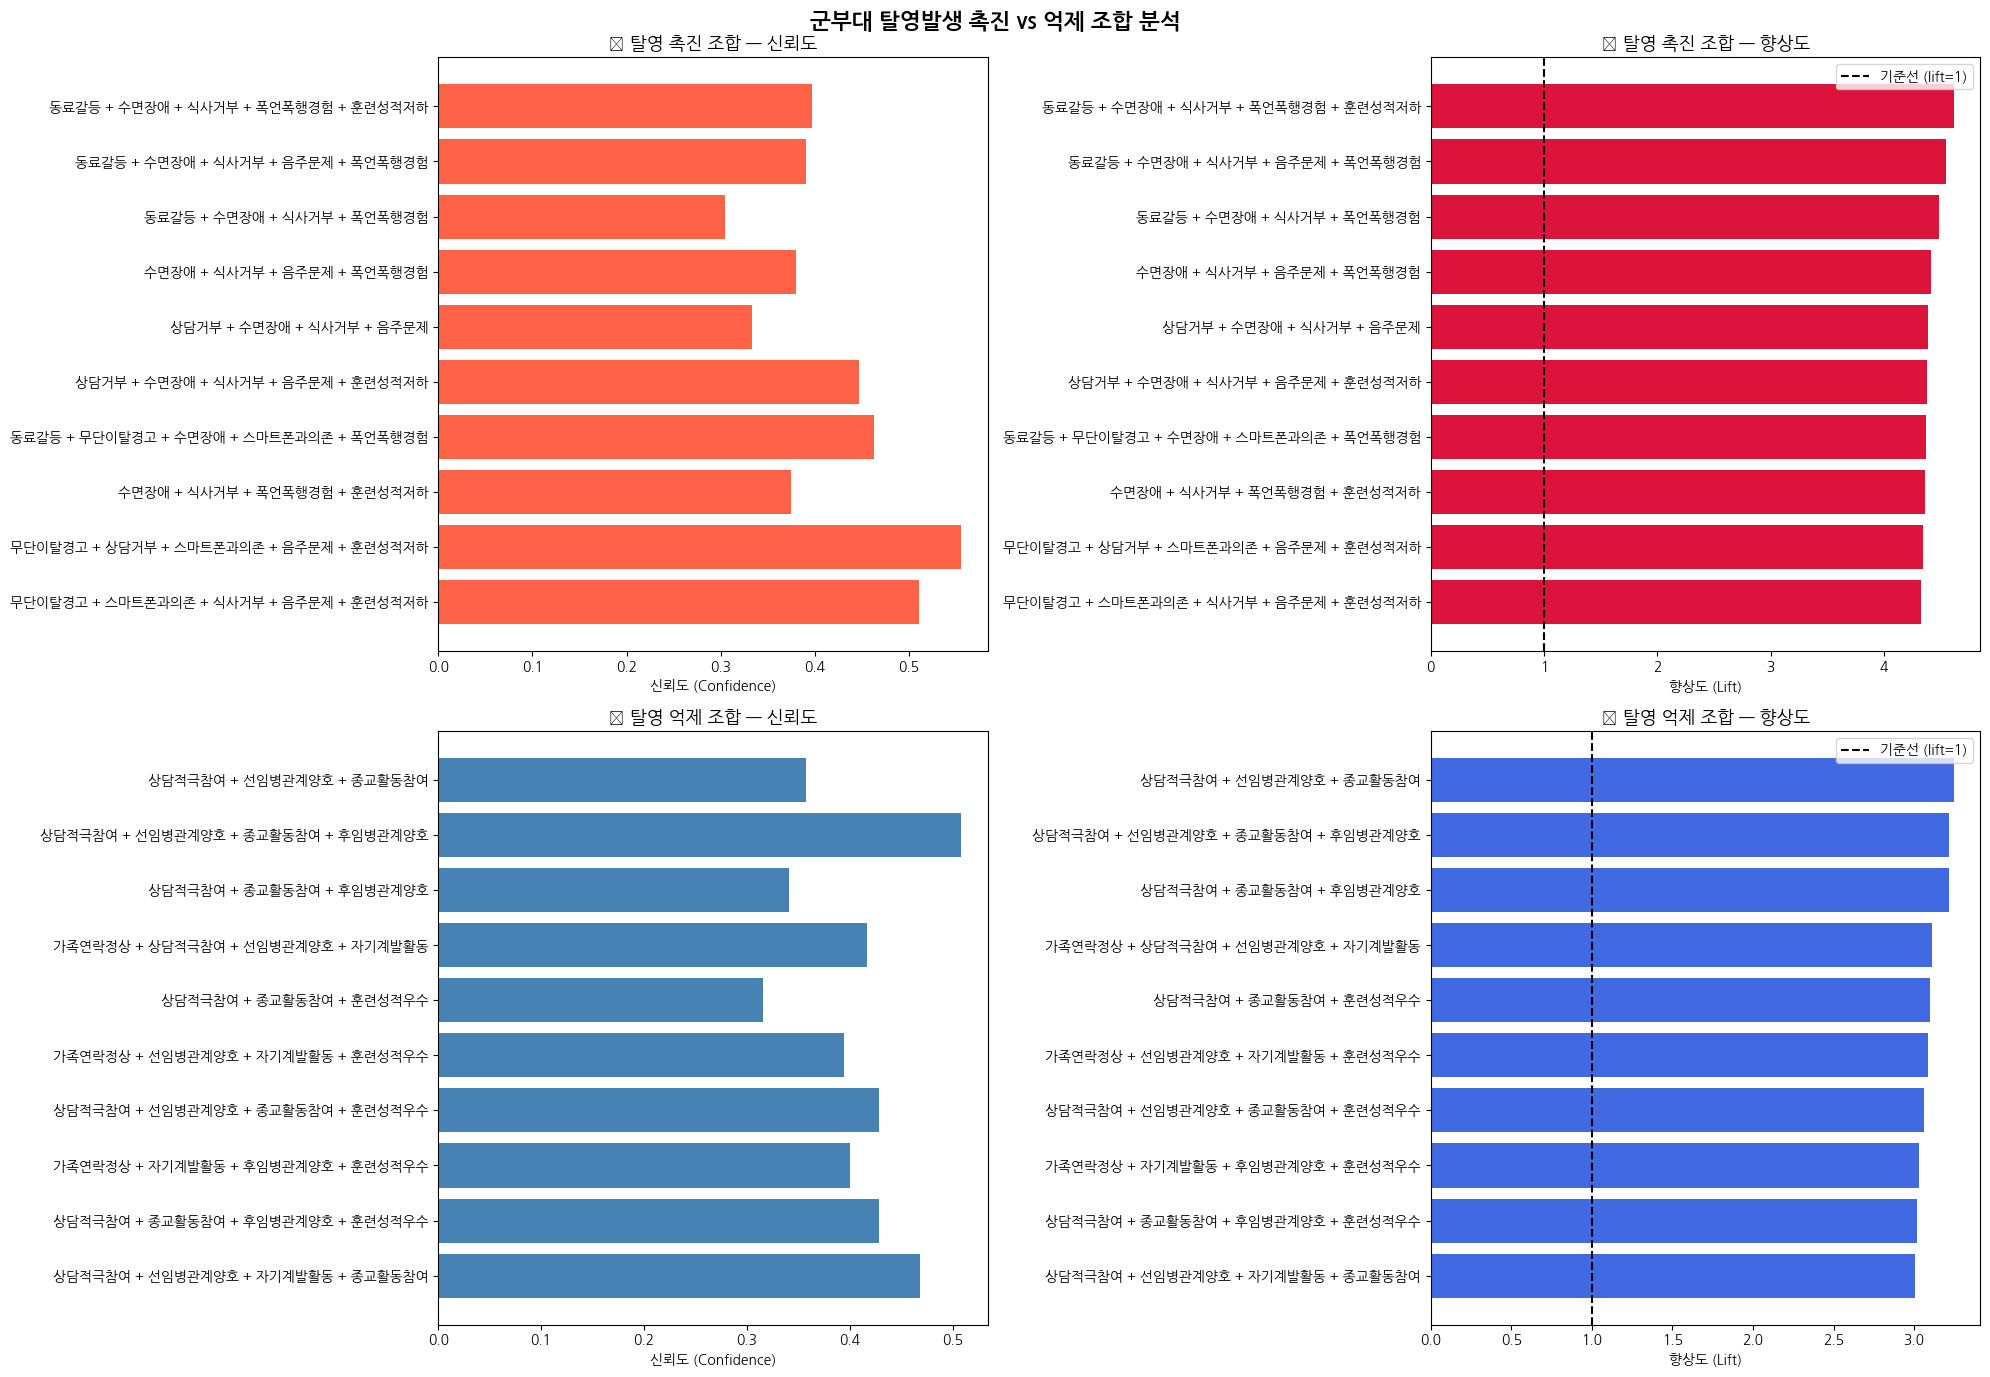

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

top10_high = rules_high.head(10)
top10_low  = rules_low.head(10)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 촉진 — 신뢰도
axes[0,0].barh(top10_high['원인조합'], top10_high['confidence'], color='tomato')
axes[0,0].set_title('🚨 탈영 촉진 조합 — 신뢰도', fontsize=13)
axes[0,0].set_xlabel('신뢰도 (Confidence)')
axes[0,0].invert_yaxis()

# 촉진 — 향상도
axes[0,1].barh(top10_high['원인조합'], top10_high['lift'], color='crimson')
axes[0,1].set_title('🚨 탈영 촉진 조합 — 향상도', fontsize=13)
axes[0,1].set_xlabel('향상도 (Lift)')
axes[0,1].axvline(x=1.0, color='black', linestyle='--', label='기준선 (lift=1)')
axes[0,1].legend()
axes[0,1].invert_yaxis()

# 억제 — 신뢰도
axes[1,0].barh(top10_low['원인조합'], top10_low['confidence'], color='steelblue')
axes[1,0].set_title('✅ 탈영 억제 조합 — 신뢰도', fontsize=13)
axes[1,0].set_xlabel('신뢰도 (Confidence)')
axes[1,0].invert_yaxis()

# 억제 — 향상도
axes[1,1].barh(top10_low['원인조합'], top10_low['lift'], color='royalblue')
axes[1,1].set_title('✅ 탈영 억제 조합 — 향상도', fontsize=13)
axes[1,1].set_xlabel('향상도 (Lift)')
axes[1,1].axvline(x=1.0, color='black', linestyle='--', label='기준선 (lift=1)')
axes[1,1].legend()
axes[1,1].invert_yaxis()

plt.suptitle('군부대 탈영발생 촉진 vs 억제 조합 분석', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

top10_high = rules_high.head(10).copy()
top10_low  = rules_low.head(10).copy()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '🚨 탈영 촉진 조합 — 신뢰도 (Confidence)',
        '🚨 탈영 촉진 조합 — 향상도 (Lift)',
        '✅ 탈영 억제 조합 — 신뢰도 (Confidence)',
        '✅ 탈영 억제 조합 — 향상도 (Lift)'
    ),
    horizontal_spacing=0.35,  # 좌우 여백 확대
    vertical_spacing=0.20     # 상하 여백 확대
)

# ── 촉진 신뢰도 ──
fig.add_trace(go.Bar(
    x=top10_high['confidence'],
    y=top10_high['원인조합'],
    orientation='h',
    marker=dict(
        color=top10_high['confidence'],
        colorscale='Reds',
        showscale=False,
        line=dict(color='rgba(0,0,0,0.3)', width=0.5)
    ),
    text=top10_high['confidence'].round(3),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>신뢰도: %{x:.3f}<extra></extra>',
    name='촉진 신뢰도'
), row=1, col=1)

# ── 촉진 향상도 ──
fig.add_trace(go.Bar(
    x=top10_high['lift'],
    y=top10_high['원인조합'],
    orientation='h',
    marker=dict(
        color=top10_high['lift'],
        colorscale='OrRd',
        showscale=False,
        line=dict(color='rgba(0,0,0,0.3)', width=0.5)
    ),
    text=top10_high['lift'].round(3),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>향상도: %{x:.3f}<extra></extra>',
    name='촉진 향상도'
), row=1, col=2)

# ── 억제 신뢰도 ──
fig.add_trace(go.Bar(
    x=top10_low['confidence'],
    y=top10_low['원인조합'],
    orientation='h',
    marker=dict(
        color=top10_low['confidence'],
        colorscale='Blues',
        showscale=False,
        line=dict(color='rgba(0,0,0,0.3)', width=0.5)
    ),
    text=top10_low['confidence'].round(3),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>신뢰도: %{x:.3f}<extra></extra>',
    name='억제 신뢰도'
), row=2, col=1)

# ── 억제 향상도 ──
fig.add_trace(go.Bar(
    x=top10_low['lift'],
    y=top10_low['원인조합'],
    orientation='h',
    marker=dict(
        color=top10_low['lift'],
        colorscale='Teal',
        showscale=False,
        line=dict(color='rgba(0,0,0,0.3)', width=0.5)
    ),
    text=top10_low['lift'].round(3),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>향상도: %{x:.3f}<extra></extra>',
    name='억제 향상도'
), row=2, col=2)

# ── 기준선 (lift=1) ──
for col in [1, 2]:
    fig.add_vline(x=1.0, line_dash='dash', line_color='gray',
                  line_width=1.5, row=2, col=col)

# ── 레이아웃 ──
fig.update_layout(
    title=dict(
        text='<b>군부대 탈영발생 촉진 vs 억제 조합 분석</b>',
        font=dict(size=20, color='#2c2c2c'),
        x=0.5, xanchor='center'
    ),
    height=1100,              # 전체 높이 확대
    showlegend=False,
    paper_bgcolor='#f8f9fa',
    plot_bgcolor='#ffffff',
    font=dict(family='Malgun Gothic, NanumGothic, sans-serif', size=10),
    margin=dict(l=20, r=20, t=80, b=20)
)

# ── 축 스타일 ──
fig.update_xaxes(showgrid=True, gridcolor='#e0e0e0', zeroline=False)
fig.update_yaxes(
    autorange='reversed',
    tickfont=dict(size=9),    # y축 글씨 크기 축소
    automargin=True           # y축 레이블 자동 여백 (핵심!)
)

# ── 서브플롯 제목 색상 ──
for i, annotation in enumerate(fig.layout.annotations):
    annotation.font.size = 12
    annotation.font.color = '#c0392b' if i < 2 else '#1a6fa8'

fig.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v